In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "IRA_2026_06_08" 
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cpu
Torch: 2.5.1+cu121  |  Torchvision: 0.20.1+cu121
Output dir: trabalho3_outputs/IRA_2026_06_08


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [2]:
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor()])

mnist = datasets.MNIST(root="data", train=True, download=True, transform=transform)
print(f"Total: {len(mnist)}")
train_ds, test_ds = random_split(mnist, [int(0.85*len(mnist)), int(0.15*len(mnist))], generator=torch.Generator().manual_seed(OWNER_SEED))

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Treino: {len(train_ds)}  |  Teste: {len(test_ds)}")

Total: 60000
Treino: 51000  |  Teste: 9000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [3]:
LATENT_DIM = 8   
IMG_DIM = 28 * 28


class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)
   

    def forward(self, x):
        # TODO: achatar x, passar pela net, retornar (mu, log_var)
        x = x.view(x.size(0), -1)
        h = self.net(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid()
        )
 

    def forward(self, z):
        h = self.net(z)
        x_hat = h.view(h.size(0), 1, 28, 28)
        return x_hat

class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):

        mu, log_var = self.encoder(x)
        z = self.reparametrize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var


model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 8  |  Parâmetros: 1,073,440


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a KL tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [4]:
def vae_loss(x, x_hat, mu, log_var):
    # TODO: BCE entre x_hat e x (reduction="sum")
    # TODO: KL fechada para prior N(0, I)
    # TODO: retornar (loss_total, recon, kl)
 
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    loss_total = recon + kl
    return loss_total, recon, kl

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

Função para rodar os experimentos:

In [53]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def run_epoch(loader, train: bool, current_model = model, optimizer = optimizer):
    # TODO: alternar entre model.train() / model.eval()
    # TODO: acumular loss, recon, kl ao longo do loader
    # TODO: se train, fazer backward + step
    # TODO: retornar médias por amostra
    if train:
        for x, _ in loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, log_var = current_model(x)
            loss_total, recon, kl = vae_loss(x, x_hat, mu, log_var)
            loss_total.backward()
            optimizer.step()
        
    else:
        with torch.no_grad():
            for x, _ in loader:
                x = x.to(device)
                x_hat, mu, log_var = model(x)
                loss_total, recon, kl = vae_loss(x, x_hat, mu, log_var)
                
    return loss_total.item() / len(loader.dataset), recon.item() / len(loader.dataset), kl.item() / len(loader.dataset)

def run_experiment(model, model_name = "vae_clean_latent", num_epochs = EPOCHS, optimizer = optimizer):

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}

    for epoch in range(1, num_epochs + 1):
        tr = run_epoch(train_loader, train=True, current_model=model, optimizer = optimizer)
        te = run_epoch(test_loader,  train=False, current_model=model, optimizer = optimizer)
        for key, value in zip(["loss", "recon", "kl"], tr):
            history[f"train_{key}"].append(value)
        for key, value in zip(["loss", "recon", "kl"], te):
            history[f"test_{key}"].append(value)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

    torch.save(model.state_dict(), output_dir / f"model_name{LATENT_DIM}.pt")
    print("Salvo.")
    return history

In [9]:
history_experiment1 = run_experiment()

Ep   1/30 | tr loss 0.11  recon 0.09  kl 0.02 | te loss 0.45
Ep   5/30 | tr loss 0.12  recon 0.10  kl 0.02 | te loss 0.45
Ep  10/30 | tr loss 0.10  recon 0.09  kl 0.02 | te loss 0.45
Ep  15/30 | tr loss 0.11  recon 0.10  kl 0.02 | te loss 0.45
Ep  20/30 | tr loss 0.11  recon 0.09  kl 0.02 | te loss 0.45
Ep  25/30 | tr loss 0.11  recon 0.10  kl 0.02 | te loss 0.45
Ep  30/30 | tr loss 0.10  recon 0.08  kl 0.02 | te loss 0.45
Salvo.


In [12]:
history_experiment1.keys()

dict_keys(['train_loss', 'train_recon', 'train_kl', 'test_loss', 'test_recon', 'test_kl'])

In [54]:
class model_list:
    def __init__(self, model_base, dict_args: dict, names):
        self.models = []
        self.model_base = model_base
        self.args = dict_args
        self.names = names
        self.set_model_list()

    def set_model_list(self):
        assert len(self.args) > 0

        hiper_list = []
        for i in range(len(self.args[0])):
            temp = []
            for key in self.args.keys():
                temp.append(self.args[key][i])
            hiper_list.append(temp)
        
        for mod in hiper_list:
            self.models.append(self.model_base(*mod))


In [55]:
def train_model_list(model_list:model_list, train_loader = train_loader):
    hist = []
    for model, name in zip(model_list.models, model_list.names):
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        history = run_experiment(model, name, train_loader, optimizer = optimizer)
        hist.append([history, name])
        
    return hist

### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

In [ ]:
# TODO: implementar as 4 visualizações 1.5a–1.5d
# - curvas de treinamento (3 subplots)
# - reconstruções (2x10)
# - espaço latente em 2D (scatter colorido por dígito; PCA se LATENT_DIM > 2)
# - amostras do prior (2x10)
# Salve as figuras em output_dir.

### 1.5a.

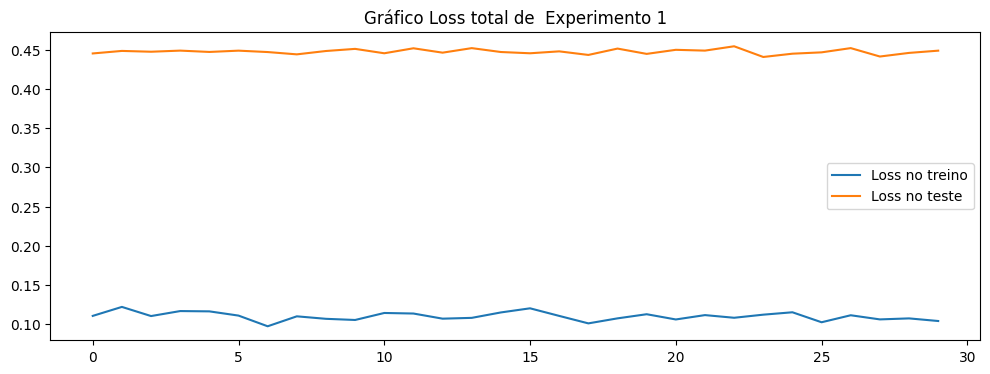

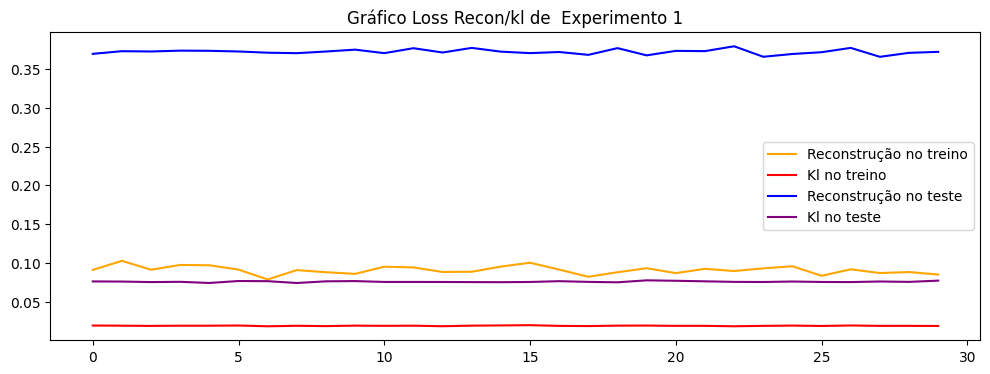

In [26]:
def plot_curves(history:dict, detail = 0, experiment_name = "Experimento X"):

    X = np.arange(len(history["train_loss"]))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(X, history["train_loss"], label = "Loss no treino")
    ax.plot(X, history["test_loss"], label = "Loss no teste")
    ax.set_title(f"Gráfico Loss total de  {experiment_name}")
    ax.legend()


    if detail:
        X = np.arange(len(history["train_loss"]))
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(X, history["train_recon"], label = "Reconstrução no treino", color = "orange")
        ax.plot(X, history["train_kl"], label = "Kl no treino", color = "red")
        ax.plot(X, history["test_recon"], label = "Reconstrução no teste", color = "blue")
        ax.plot(X, history["test_kl"], label = "Kl no teste", color = "purple")
        ax.set_title(f"Gráfico Loss Recon/kl de  {experiment_name}")
        ax.legend()


plot_curves(history_experiment1, 1, "Experimento 1")

### 1.5b.

### 1.5d.

In [ ]:
def sample_recons(model, latent_dim=16, num_samples=50, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval() 
    
    with torch.no_grad():
        zs = torch.randn(num_samples, latent_dim).to(device)
        generated_images = model.decoder(zs)
        generated_images = generated_images.cpu().numpy()

    cols = min(10, num_samples) 
    rows = (num_samples + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i in range(len(axes)):
        ax = axes[i]

        if i >= num_samples:
            ax.axis('off')
            continue
            
        img = generated_images[i]
        
        if img.ndim == 3:
            img = np.transpose(img, (1, 2, 0))
            
        if img.shape[-1] == 1:
            img = img.squeeze(-1)
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

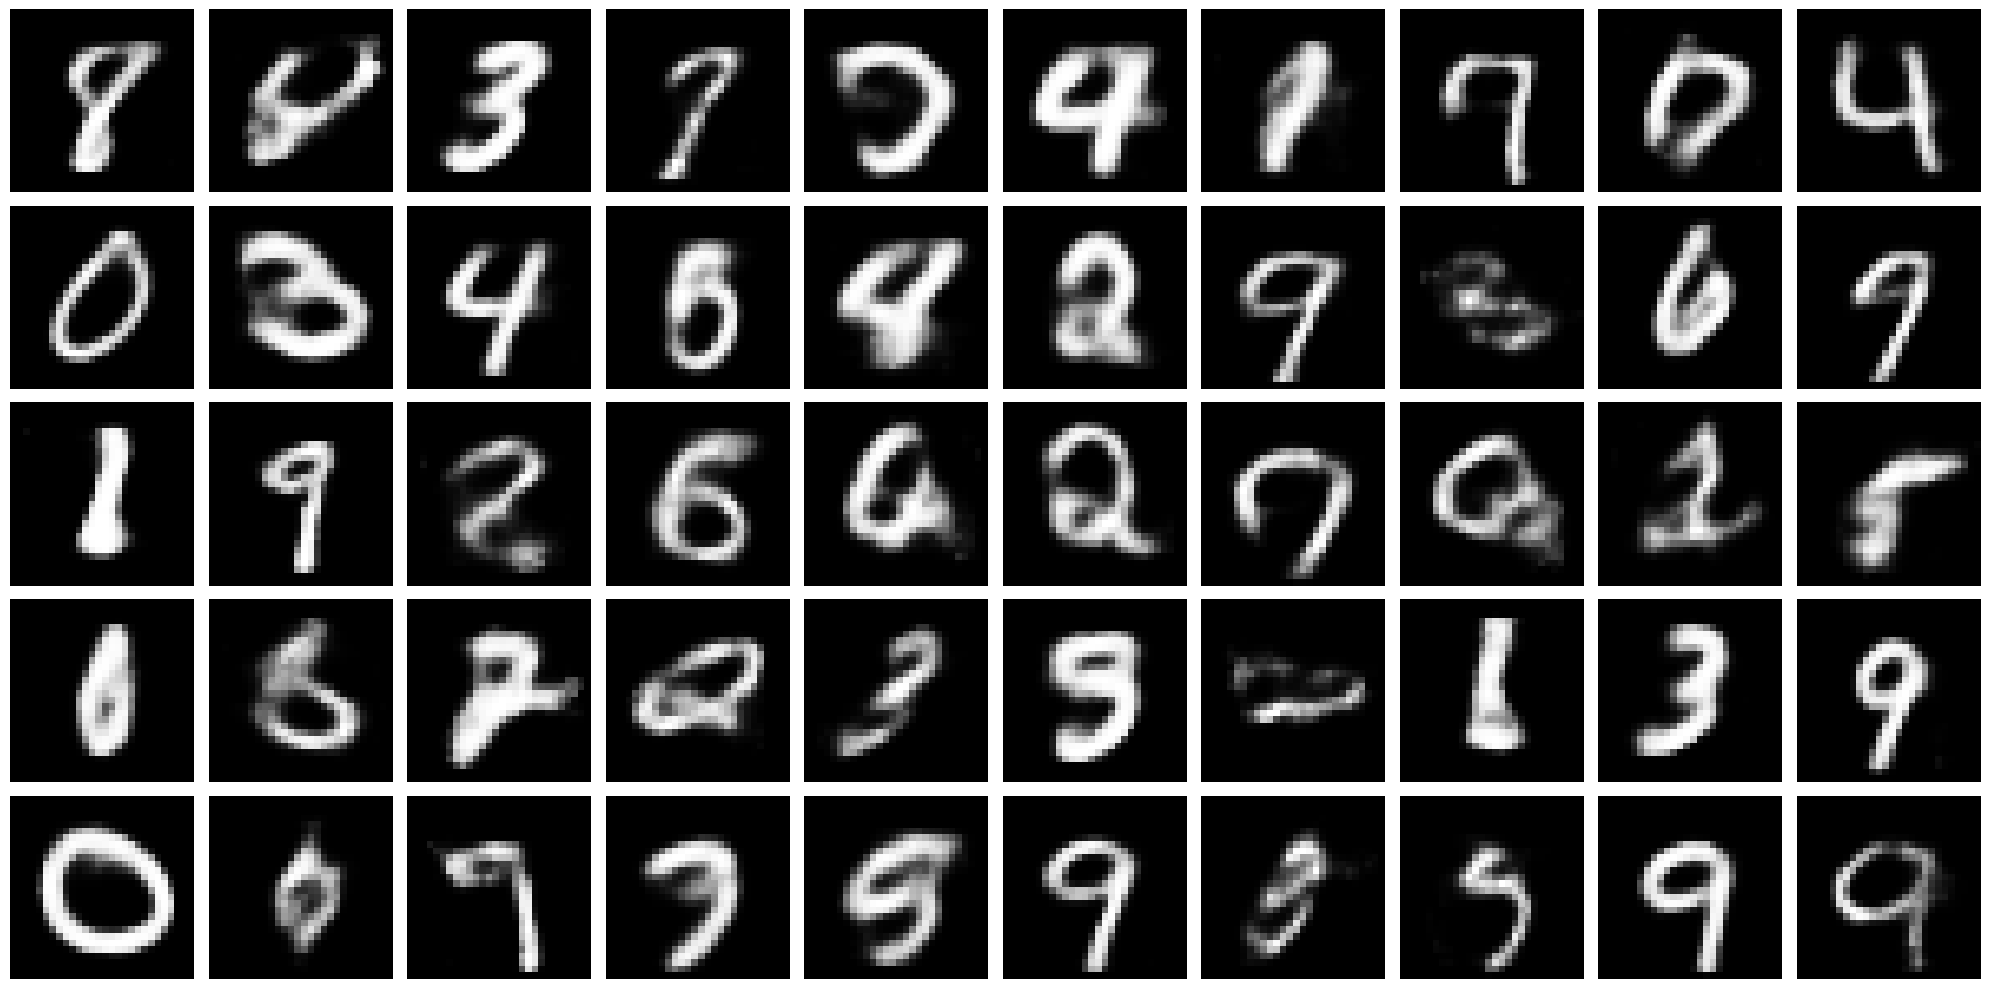

In [59]:
sample_recons(model, latent_dim = 8)

### 1.5c.

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

*Escreva sua resposta aqui (a, b, c).*

## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [ ]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20


def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # TODO: clone e estampe um quadrado branco PATCH_SIZE x PATCH_SIZE
    raise NotImplementedError


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        # TODO: amostrar índices a marcar (use np.random.default_rng(seed))
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        # TODO: retornar (img marcada se idx in indices else img, label)
        raise NotImplementedError


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

In [ ]:
# TODO: mostre 10 amostras originais e suas versões marcadas (2x10 grid)
raise NotImplementedError

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [ ]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # TODO: criar VAE(latent_dim), Adam, loop de épocas
    # TODO: print resumo a cada N épocas
    raise NotImplementedError


vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")

### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

In [ ]:
N = 20
# TODO: amostre o mesmo z, decodifique nos 2 modelos, plote lado a lado
raise NotImplementedError

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

In [ ]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # TODO: retornar média de pixels na região do patch, por imagem
    raise NotImplementedError


N_AUDIT = 1000
# TODO: computar patch_mean para os 4 grupos, plotar bar chart, calcular lift
raise NotImplementedError

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

*Escreva suas respostas aqui (a, b, c).*

## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

In [ ]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

In [ ]:
def apply_ss_watermark(img):
    # TODO
    raise NotImplementedError


class SpreadSpectrumMNIST(Dataset):
    # TODO
    pass


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# TODO: visualizar original vs marcado vs (marcado-original)*5

### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [ ]:
ss_loader = DataLoader(ss_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
# TODO: treine vae_ss e salve
raise NotImplementedError

### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

In [ ]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    raise NotImplementedError


N_AUDIT = 2000
model.eval(); vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
raise NotImplementedError

### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

In [ ]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
raise NotImplementedError

### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

In [ ]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO: <x - mean_img, pattern>
    raise NotImplementedError


# TODO: recomputar os scores e replotar o histograma centrado
raise NotImplementedError

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

In [ ]:
N_AUDIT = 2000

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
# Compute sc_clean e sc_ss usando corr_score_centered
# Compute o t-estatístico de duas amostras
raise NotImplementedError

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

*Escreva suas respostas aqui (a, b, c).*

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [ ]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [...]   # ex: [0.05, 0.10]
FRACTION_VALUES = [...]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = ...     # pode ser menor que EPOCHS — veja a dica acima

def make_ss_dataset(eps, fraction, seed=SEED):
    # TODO: retornar um Dataset que aplica a marca em `fraction` das imagens de treino
    # com amplitude `eps`
    raise NotImplementedError

# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
model_ab = ...
raise NotImplementedError

### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [ ]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
results = []
raise NotImplementedError

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

In [ ]:
# TODO: heatmap signal_grid, heatmap t_grid
raise NotImplementedError

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

*Escreva suas respostas aqui (a, b, c).*

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

*Escreva sua resposta aqui (tabela + análise).*

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |